# SBI Galactic Acceleration vs Redshift — Quaia Quasar Proper Motions

Runs the full SBI pipeline for each of 5 quantile redshift bins of the Quaia catalog.
Saves posterior samples per bin; produces `gxyz_vs_z_quaia.pdf` and `gmag_vs_z_quaia.pdf`.

**Resume-safe:** each bin is skipped if `output/zbins/zbin_{i}.npz` already exists.

In [ ]:
import os
import functools
import numpy as np
import healpy as hp
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import stats

from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon
from itertools import combinations

from sbi.inference import SNPE
from sbi import utils as utils
from sbi.utils.user_input_checks import check_sbi_inputs, process_prior, process_simulator
from sbi.inference import simulate_for_sbi

from sbi_hpm.geometry import SkyFunction
from sbi_hpm.data import load_gaia_qso, compute_pixel_stats
from sbi_hpm.forward_model import WeightedSHT
from sbi_hpm.sbi_setup import (
    n_real_params, build_full_alm_complex,
    precompute_noise_cholesky, generate_pixel_noise,
    simulator_full,
)

mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Liberation Serif'],
    'text.latex.preamble': r'\usepackage{newtxtext}\usepackage{newtxmath}',
})

/home/phuy2808/Astrophysis/Intern_apc/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH    = r'/home/phuy2808/Astrophysis/Intern_apc/quaia_G20.0_with_pmra_pmdec_corr.csv'
OUT_DIR      = 'output/zbins'
os.makedirs(OUT_DIR, exist_ok=True)

N_BINS       = 5
nside        = 64
npix         = hp.nside2npix(nside)
galcut       = 0        # degrees
lmax_sig     = 3
lmax_fit     = 10
n_simulations = 100_000
n_posterior   = 10_000
alm_bound     = 50e-3   # mas/yr
Cl_bound      = 50e-6   # (mas/yr)²

n_alm_l3  = n_real_params(lmax_sig)         # 30
n_Cl      = 2 * (lmax_fit - lmax_sig)       # 14
n_theta   = n_alm_l3 + n_Cl                 # 44
dipole_idx = np.array([0, lmax_sig, lmax_sig + 1])  # [0, 3, 4]

skyfunc = SkyFunction(nside=nside)

print(f'θ dim: {n_theta}  ({n_alm_l3} alm  +  {n_Cl} Cl)')

θ dim: 44  (30 alm  +  14 Cl)


In [3]:
# ── Load Quaia and define z bins ──────────────────────────────────────────────
quaia = load_gaia_qso(DATA_PATH)
quaia['z_bin'], z_bin_edges = pd.qcut(
    quaia['redshift_quaia'], q=N_BINS, labels=False, retbins=True
)
z_centers = 0.5 * (z_bin_edges[:-1] + z_bin_edges[1:])
z_widths  = 0.5 * (z_bin_edges[1:]  - z_bin_edges[:-1])

print(f'Total sources: {len(quaia):,}')
print(f'Z bin edges:   {np.round(z_bin_edges, 3)}')
print(f'Z centers:     {np.round(z_centers,  3)}')
for i in range(N_BINS):
    n = (quaia['z_bin'] == i).sum()
    print(f'  Bin {i}  z=[{z_bin_edges[i]:.3f}, {z_bin_edges[i+1]:.3f}]  n={n:,}')

Total sources: 755,850
Z bin edges:   [0.084 0.856 1.262 1.637 2.135 4.537]
Z centers:     [0.47  1.059 1.45  1.886 3.336]
  Bin 0  z=[0.084, 0.856]  n=151,170
  Bin 1  z=[0.856, 1.262]  n=151,170
  Bin 2  z=[1.262, 1.637]  n=151,170
  Bin 3  z=[1.637, 2.135]  n=151,170
  Bin 4  z=[2.135, 4.537]  n=151,170


In [4]:
# ── Prior (same for all bins) ─────────────────────────────────────────────────
low_full  = torch.cat([-alm_bound * torch.ones(n_alm_l3), torch.zeros(n_Cl)])
high_full = torch.cat([ alm_bound * torch.ones(n_alm_l3), Cl_bound * torch.ones(n_Cl)])
prior_full = utils.BoxUniform(low=low_full, high=high_full)

prior_proc, _, prior_np = process_prior(prior_full)

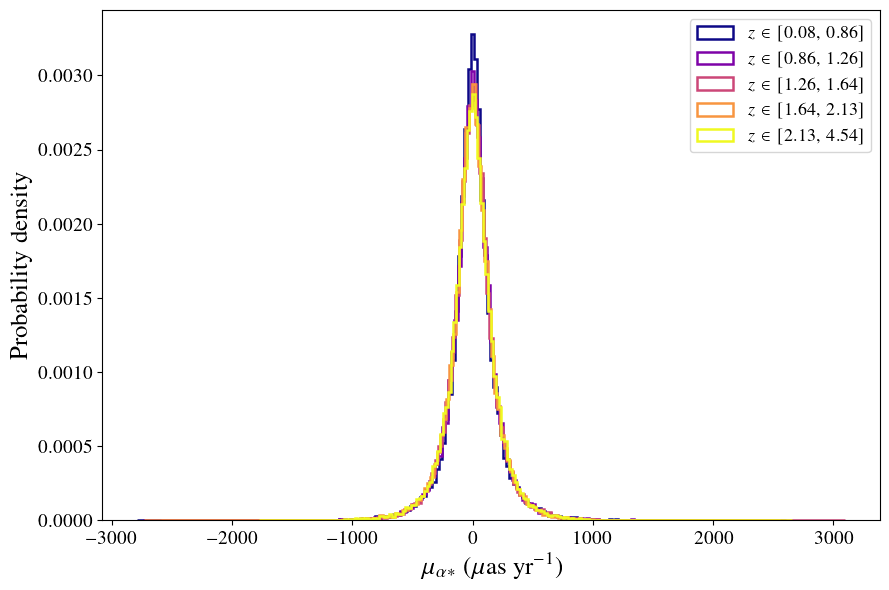

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('plasma', N_BINS)

for i in range(N_BINS):
    sel = quaia['z_bin'] == i
    pix_i = compute_pixel_stats(
        quaia['ra'].values[sel],
        quaia['dec'].values[sel],
        quaia['pmra'].values[sel],
        quaia['pmdec'].values[sel],
        quaia['pmra_error'].values[sel],
        quaia['pmdec_error'].values[sel],
        quaia['pmra_pmdec_corr'].values[sel],
        nside=nside, galcut=galcut,
    )
    mask_i   = pix_i['mask']
    pmra_i   = pix_i['pmra_wm'][mask_i] * 1e3   # mas/yr → µas/yr
    label    = rf'$z \in [{z_bin_edges[i]:.2f},\,{z_bin_edges[i+1]:.2f}]$'
    ax.hist(pmra_i, bins=200, density=True, histtype='step',
            linewidth=1.8, color=cmap(i), label=label)

ax.set_xlabel(r'$\mu_{\alpha*}$ ($\mu$as yr$^{-1}$)', fontsize=18)
ax.set_ylabel('Probability density', fontsize=18)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
#ax.set_xlim(np.percentile(pmra_i, 0.5), np.percentile(pmra_i, 99.5))
plt.tight_layout()
plt.show()

In [ ]:
# Main loop: one SBI run per z bin 
for i in range(N_BINS):
    out_path = os.path.join(OUT_DIR, f'zbin_{i}.npz')

    if os.path.exists(out_path):
        print(f'[Bin {i}] Found {out_path} — skipping.')
        continue

    print(f'\n══ Bin {i}  z=[{z_bin_edges[i]:.3f}, {z_bin_edges[i+1]:.3f}] ══')

    # 1. Filter sources
    sel = quaia['z_bin'] == i
    ra_b       = quaia['ra'].values[sel]
    dec_b      = quaia['dec'].values[sel]
    pmra_b     = quaia['pmra'].values[sel]
    pmdec_b    = quaia['pmdec'].values[sel]
    sig_pmra_b = quaia['pmra_error'].values[sel]
    sig_pmdec_b= quaia['pmdec_error'].values[sel]
    pm_corr_b  = quaia['pmra_pmdec_corr'].values[sel]
    print(f'  Sources: {sel.sum():,}')

    # 2. Pixelize
    pix = compute_pixel_stats(
        ra_b, dec_b, pmra_b, pmdec_b,
        sig_pmra_b, sig_pmdec_b, pm_corr_b,
        nside=nside, galcut=galcut,
    )
    pmra_wm   = pix['pmra_wm']
    pmdec_wm  = pix['pmdec_wm']
    mask_b    = pix['mask']

    sig_pmra_safe  = np.where(np.isfinite(pix['sig_pmra_wm']),  pix['sig_pmra_wm'],  0.0)
    sig_pmdec_safe = np.where(np.isfinite(pix['sig_pmdec_wm']), pix['sig_pmdec_wm'], 0.0)
    pm_corr_safe   = np.nan_to_num(pix['pm_corr_wm'], nan=0.0)
    print(f'  Valid pixels: {mask_b.sum():,}')

    # 3. Solver + LU
    solver_b = WeightedSHT(
        nside, mask_b,
        pmra_wm, pmdec_wm,
        sig_pmra_safe, sig_pmdec_safe, pm_corr_safe,
    )
    print('  Building LU factorizations...')
    solver_b.build_lu(lmax_fit)
    solver_b.build_lu(lmax_sig)

    # 4. Observed summary statistics
    best_fit_l10 = solver_b.solve_fast(pmra_wm, pmdec_wm, lmax_fit)
    best_fit_l3  = solver_b.solve_fast(pmra_wm, pmdec_wm, lmax_sig)
    x_obs_b      = torch.tensor(best_fit_l10, dtype=torch.float32)
    g_obs_b      = np.array(skyfunc.s2g(best_fit_l3[dipole_idx] * 1e3))
    print(f'  MAP dipole: gx={g_obs_b[0]:.2f}  gy={g_obs_b[1]:.2f}  gz={g_obs_b[2]:.2f}  µas/yr')

    # 5. Noise Cholesky
    L11, L21, L22, valid_pix_b = precompute_noise_cholesky(
        sig_pmra_safe, sig_pmdec_safe, pm_corr_safe, mask_b, npix
    )
    print(f'  Noise valid pixels: {valid_pix_b.sum():,}')

    # 6. Simulator
    _sim = functools.partial(
        simulator_full,
        solver=solver_b, L11=L11, L21=L21, L22=L22,
        valid_pix=valid_pix_b, npix=npix,
        lmax_sig=lmax_sig, lmax_fit=lmax_fit,
        n_alm_l3=n_alm_l3, n_Cl=n_Cl,
    )
    sim_wrapped = lambda theta: _sim(theta)[0]
    sim_proc = process_simulator(sim_wrapped, prior_proc, prior_np)
    check_sbi_inputs(sim_proc, prior_proc)

    # 7. Simulate
    print(f'  Running {n_simulations:,} simulations...')
    theta_sims, x_sims = simulate_for_sbi(
        sim_proc, proposal=prior_proc, num_simulations=n_simulations,
    )

    # 8. Train SNPE
    print('  Training SNPE...')
    inference = SNPE(prior=prior_proc)
    inference = inference.append_simulations(theta_sims, x_sims)
    de = inference.train()
    posterior_b = inference.build_posterior(de)

    # 9. Sample posterior
    print(f'  Sampling {n_posterior:,} posterior draws...')
    samples_b = posterior_b.sample((n_posterior,), x=x_obs_b)
    samples_np = samples_b.detach().cpu().numpy()

    # 10. Extract g
    g_full_b = np.apply_along_axis(
        lambda t: skyfunc.s2g(t[dipole_idx] * 1e3),
        axis=1, arr=samples_np,
    )   # (n_posterior, 3)

    # 11. Save
    np.savez(
        out_path,
        g_full    = g_full_b,
        g_obs     = g_obs_b,
        z_center  = z_centers[i],
        z_edges   = z_bin_edges[i:i+2],
    )
    print(f'  Saved {out_path}')

print('\nAll bins done.')

[Bin 0] Found output/zbins/zbin_0.npz — skipping.
[Bin 1] Found output/zbins/zbin_1.npz — skipping.
[Bin 2] Found output/zbins/zbin_2.npz — skipping.
[Bin 3] Found output/zbins/zbin_3.npz — skipping.
[Bin 4] Found output/zbins/zbin_4.npz — skipping.

All bins done.


In [ ]:
#  Load all bin results 
results = [np.load(os.path.join(OUT_DIR, f'zbin_{i}.npz')) for i in range(N_BINS)]

z_c   = np.array([r['z_center'] for r in results])
z_w   = z_widths   # half-widths for x error bars
g_obs_all = np.array([r['g_obs'] for r in results])   # (N_BINS, 3)

# Per-component percentiles
q16 = np.array([np.percentile(r['g_full'], 16, axis=0) for r in results])  # (N_BINS, 3)
q50 = np.array([np.percentile(r['g_full'], 50, axis=0) for r in results])
q84 = np.array([np.percentile(r['g_full'], 84, axis=0) for r in results])

err_lo = q50 - q16   # (N_BINS, 3)
err_hi = q84 - q50

# |g| per sample
def g_mag_stats(g_full):
    mag = np.linalg.norm(g_full, axis=1)
    return np.percentile(mag, [16, 50, 84])

mag_stats = np.array([g_mag_stats(r['g_full']) for r in results])  # (N_BINS, 3)
mag_lo = mag_stats[:, 1] - mag_stats[:, 0]
mag_hi = mag_stats[:, 2] - mag_stats[:, 1]

print('Loaded results for all bins.')
print(f'{'Bin':>4}  {'z':>6}  {'gx':>8}  {'gy':>8}  {'gz':>8}  {'|g|':>8}')
for i in range(N_BINS):
    print(f'{i:>4}  {z_c[i]:>6.3f}  '
          f'{q50[i,0]:>+7.2f}  {q50[i,1]:>+7.2f}  {q50[i,2]:>+7.2f}  '
          f'{mag_stats[i,1]:>7.2f}  µas/yr')

Loaded results for all bins.
 Bin       z        gx        gy        gz       |g|
   0   0.470    +0.97    -3.51    -3.89     5.48  µas/yr
   1   1.059    +1.88    -3.32    -1.12     4.23  µas/yr
   2   1.450    -0.40    -5.23    -2.98     6.25  µas/yr
   3   1.886    -1.61    -5.58    -3.36     6.95  µas/yr
   4   3.336    +0.47    -6.28    -3.99     7.68  µas/yr


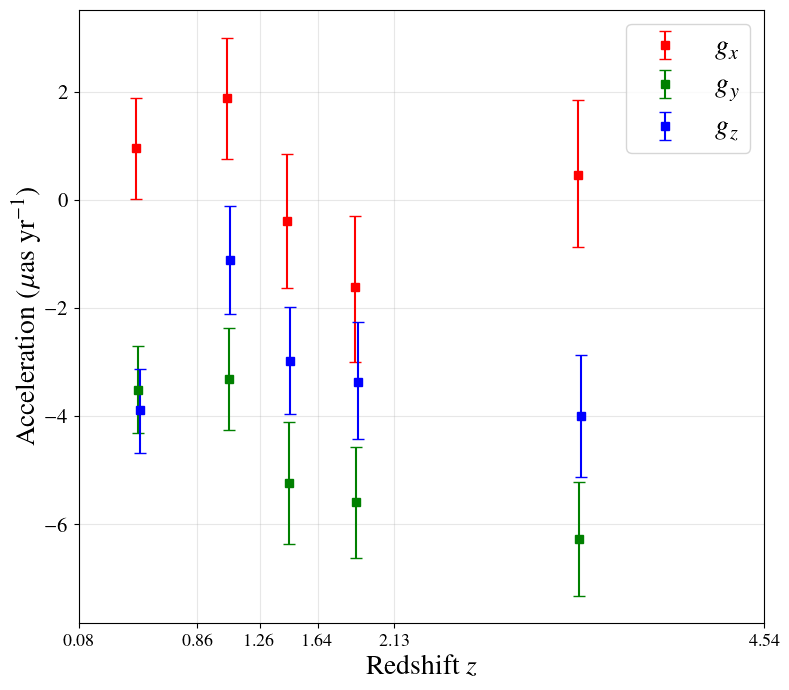

Saved output/zbins/gxyz_vs_z_quaia.pdf


In [ ]:
#  Plot: gxyz_vs_z_quaia.pdf 
colors_g = ['red', 'green', 'blue']
g_names  = [r'$g_x$', r'$g_y$', r'$g_z$']
offsets  = [-0.01, 0.0, 0.01]   # horizontal jitter to separate components

fig, ax = plt.subplots(figsize=(8, 7))

for k, (name, color, offset) in enumerate(zip(g_names, colors_g, offsets)):
    ax.errorbar(
        z_c + offset, q50[:, k],
        yerr=[err_lo[:, k], err_hi[:, k]],
        fmt='s', color=color, capsize=4, lw=1.5, markersize=6,
        label=name,
    )

ax.set_xlabel('Redshift $z$', fontsize=20)
ax.set_ylabel(r'Acceleration ($\mu$as yr$^{-1}$)', fontsize=20)
ax.tick_params(labelsize=15)
ax.legend(fontsize=20)
ax.set_xticks(z_bin_edges)
ax.set_xticklabels([f'{z:.2f}' for z in z_bin_edges], fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_gxyz = os.path.join(OUT_DIR, 'gxyz_vs_z_quaia.pdf')
plt.savefig(out_gxyz, bbox_inches='tight')
plt.show()
print(f'Saved {out_gxyz}')

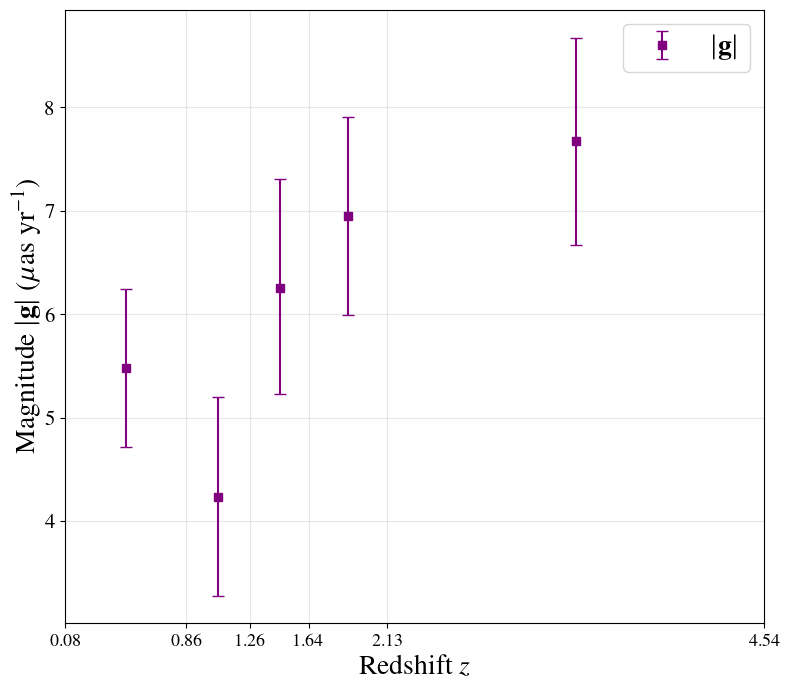

Saved output/zbins/gmag_vs_z_quaia.pdf


In [ ]:
#  Plot: gmag_vs_z_quaia.pdf 
fig, ax = plt.subplots(figsize=(8, 7))

ax.errorbar(
    z_c, mag_stats[:, 1],
    #xerr=z_w,
    yerr=[mag_lo, mag_hi],
    fmt='s', color='purple', capsize=4, lw=1.5, markersize=6,
    label=r'$|\mathbf{g}|$',
)

ax.set_xlabel('Redshift $z$', fontsize=20)
ax.set_ylabel(r'Magnitude $|\mathbf{g}|$ ($\mu$as yr$^{-1}$)', fontsize=20)
ax.tick_params(labelsize=15)
ax.legend(fontsize=20)
ax.set_xticks(z_bin_edges)
ax.set_xticklabels([f'{z:.2f}' for z in z_bin_edges], fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_gmag = os.path.join(OUT_DIR, 'gmag_vs_z_quaia.pdf')
plt.savefig(out_gmag, bbox_inches='tight')
plt.show()
print(f'Saved {out_gmag}')

Chi-squared consistency test  (H0: z-independent acceleration)
  gx:  mean=+0.46±0.52  χ²/dof=4.7/4  p=0.314  → CONSISTENT
  gy:  mean=-4.57±0.43  χ²/dof=7.5/4  p=0.114  → CONSISTENT
  gz:  mean=-3.12±0.43  χ²/dof=5.7/4  p=0.221  → CONSISTENT
 |g|:  mean=+6.02±0.42  χ²/dof=7.7/4  p=0.104  → CONSISTENT


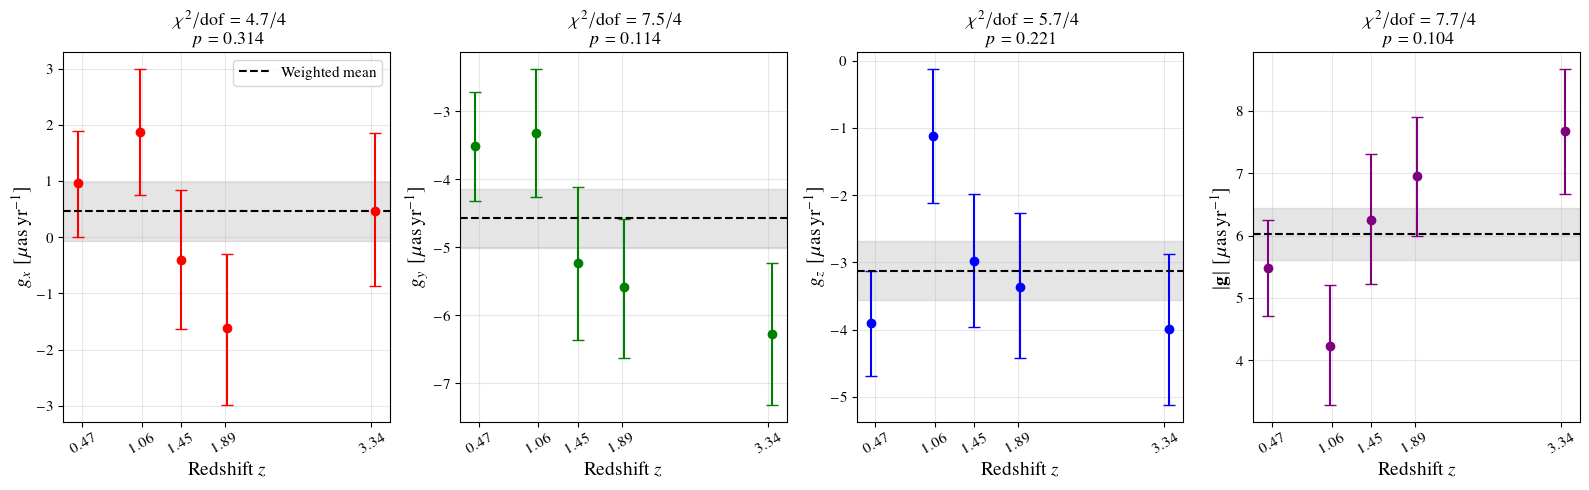

Saved output/zbins/chi2_consistency_zbins.pdf


In [ ]:
#  Chi-squared consistency test + plot 
# H0: all bins measure same (gx, gy, gz) — expected for SSB acceleration

component_names_g = ['gx', 'gy', 'gz']
colors_chi = ['red', 'green', 'blue']

chi2_results = {}
for k, cname in enumerate(component_names_g):
    vals   = q50[:, k]
    errs   = 0.5 * (err_lo[:, k] + err_hi[:, k])
    w      = 1.0 / errs**2
    g_wmean = np.sum(w * vals) / np.sum(w)
    g_werr  = 1.0 / np.sqrt(np.sum(w))
    chi2    = np.sum(w * (vals - g_wmean)**2)
    dof     = N_BINS - 1
    pval    = 1.0 - stats.chi2.cdf(chi2, df=dof)
    chi2_results[cname] = dict(wmean=g_wmean, werr=g_werr,
                                chi2=chi2, dof=dof, pval=pval)

# |g|
mag_vals  = mag_stats[:, 1]
mag_errs  = 0.5 * (mag_lo + mag_hi)
w_mag     = 1.0 / mag_errs**2
mag_wmean = np.sum(w_mag * mag_vals) / np.sum(w_mag)
mag_werr  = 1.0 / np.sqrt(np.sum(w_mag))
chi2_mag  = np.sum(w_mag * (mag_vals - mag_wmean)**2)
pval_mag  = 1.0 - stats.chi2.cdf(chi2_mag, df=N_BINS - 1)
chi2_results['|g|'] = dict(wmean=mag_wmean, werr=mag_werr,
                            chi2=chi2_mag, dof=N_BINS-1, pval=pval_mag)

# print summary 
print('Chi-squared consistency test  (H0: z-independent acceleration)')
print('=' * 60)
for cname, res in chi2_results.items():
    flag = ('CONSISTENT' if res['pval'] > 0.05
            else 'marginal' if res['pval'] > 0.01 else 'SIGNIFICANT')
    print(f"{cname:>4}:  mean={res['wmean']:+.2f}±{res['werr']:.2f}  "
          f"χ²/dof={res['chi2']:.1f}/{res['dof']}  "
          f"p={res['pval']:.3f}  → {flag}")

# plot 
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
all_names  = ['gx', 'gy', 'gz', '|g|']
all_colors = ['red', 'green', 'blue', 'purple']
offsets_x  = np.linspace(-0.04, 0.04, N_BINS)

for ax, cname, color in zip(axes, all_names, all_colors):
    res = chi2_results[cname]

    if cname == '|g|':
        vals = mag_vals; errs_lo = mag_lo; errs_hi = mag_hi
    else:
        k = ['gx','gy','gz'].index(cname)
        vals = q50[:, k]; errs_lo = err_lo[:, k]; errs_hi = err_hi[:, k]

    for i in range(N_BINS):
        ax.errorbar(z_centers[i] + offsets_x[i], vals[i],
                    yerr=[[errs_lo[i]], [errs_hi[i]]],
                    fmt='o', color=color, capsize=4, markersize=6, lw=1.5)

    # Weighted mean band
    ax.axhline(res['wmean'], color='k', lw=1.5, linestyle='--', label='Weighted mean')
    ax.axhspan(res['wmean'] - res['werr'], res['wmean'] + res['werr'],
               color='gray', alpha=0.2)

    ax.set_xlabel('Redshift $z$', fontsize=14)
    if cname == '|g|':
        ax.set_ylabel(r'$|\mathbf{g}|\ [\mu\mathrm{as\,yr}^{-1}]$', fontsize=14)
    else:
        ax.set_ylabel(rf'$g_{cname[1]}\ [\mu\mathrm{{as\,yr}}^{{-1}}]$', fontsize=14)
    ax.set_title(
        rf'$\chi^2/\mathrm{{dof}}={res["chi2"]:.1f}/{res["dof"]}$'
        + '\n'
        + rf'$p={res["pval"]:.3f}$',
        fontsize=13,
    )
    ax.set_xticks(z_bin_edges[:-1] + z_widths)
    ax.set_xticklabels([f'{z:.2f}' for z in z_centers], fontsize=10, rotation=30)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'chi2_consistency_zbins.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved {os.path.join(OUT_DIR, "chi2_consistency_zbins.pdf")}')

Jensen-Shannon divergence (KDE) between z-bin pairs
(JS=0: identical  |  JS=1: no overlap)

gx:
  z0(z=0.47) vs z1(z=1.06):  JS=0.0939  → mild tension
  z0(z=0.47) vs z2(z=1.45):  JS=0.1633  → INCONSISTENT
  z0(z=0.47) vs z3(z=1.89):  JS=0.3880  → INCONSISTENT
  z0(z=0.47) vs z4(z=3.34):  JS=0.0495  → consistent
  z1(z=1.06) vs z2(z=1.45):  JS=0.3112  → INCONSISTENT
  z1(z=1.06) vs z3(z=1.89):  JS=0.4939  → INCONSISTENT
  z1(z=1.06) vs z4(z=3.34):  JS=0.1354  → mild tension
  z2(z=1.45) vs z3(z=1.89):  JS=0.1008  → mild tension
  z2(z=1.45) vs z4(z=3.34):  JS=0.0544  → mild tension
  z3(z=1.89) vs z4(z=3.34):  JS=0.2311  → INCONSISTENT

gy:
  z0(z=0.47) vs z1(z=1.06):  JS=0.0132  → consistent
  z0(z=0.47) vs z2(z=1.45):  JS=0.2882  → INCONSISTENT
  z0(z=0.47) vs z3(z=1.89):  JS=0.3932  → INCONSISTENT
  z0(z=0.47) vs z4(z=3.34):  JS=0.5197  → INCONSISTENT
  z1(z=1.06) vs z2(z=1.45):  JS=0.2971  → INCONSISTENT
  z1(z=1.06) vs z3(z=1.89):  JS=0.3968  → INCONSISTENT
  z1(z=1.06) vs z4(z=3.

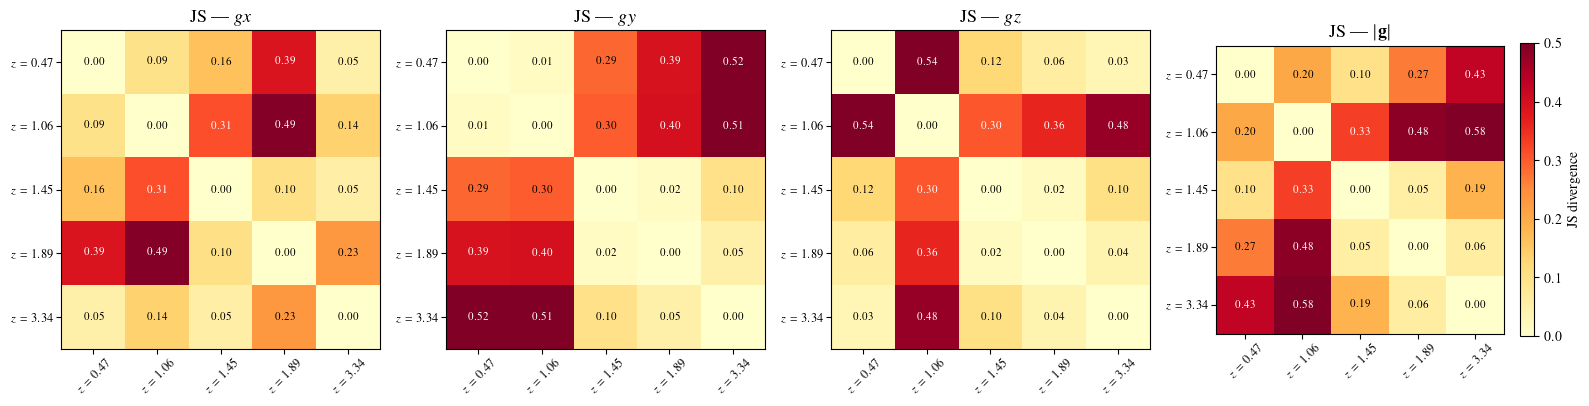

Saved output/zbins/js_heatmap_zbins.pdf


In [ ]:
#  Jensen-Shannon divergence between z-bin posteriors 
# Uses KDE on posterior samples in case of asymmetric/skewed posteriors
# JS ∈ [0, 1]: 0 = identical distributions, 1 = no overlap

component_names = ['gx', 'gy', 'gz', '|g|']

# Build per-bin arrays: (n_posterior, 4)
g_samples = []
for r in results:
    gf  = r['g_full']
    mag = np.linalg.norm(gf, axis=1, keepdims=True)
    g_samples.append(np.hstack([gf, mag]))

def js_kde(a, b, n_grid=500):
    """JS divergence via KDE — handles asymmetric posteriors."""
    lo = min(a.min(), b.min()) - 0.5 * (max(a.max(), b.max()) - min(a.min(), b.min()))
    hi = max(a.max(), b.max()) + 0.5 * (max(a.max(), b.max()) - min(a.min(), b.min()))
    grid = np.linspace(lo, hi, n_grid)
    pa = gaussian_kde(a)(grid);  pa /= pa.sum()
    pb = gaussian_kde(b)(grid);  pb /= pb.sum()
    return jensenshannon(pa, pb) ** 2   # jensenshannon returns sqrt(JS)

#  Text output 
print('Jensen-Shannon divergence (KDE) between z-bin pairs')
print('(JS=0: identical  |  JS=1: no overlap)')
print('=' * 60)
for k, cname in enumerate(component_names):
    print(f'\n{cname}:')
    for i, j in combinations(range(N_BINS), 2):
        js = js_kde(g_samples[i][:, k], g_samples[j][:, k])
        zi = f'z{i}(z={z_centers[i]:.2f})'
        zj = f'z{j}(z={z_centers[j]:.2f})'
        interp = 'consistent' if js < 0.05 else ('mild tension' if js < 0.15 else 'INCONSISTENT')
        print(f'  {zi} vs {zj}:  JS={js:.4f}  → {interp}')

#  Heatmap plot 
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
bin_labels = [f'$z={z_centers[i]:.2f}$' for i in range(N_BINS)]

for ax, k, cname in zip(axes, range(4), component_names):
    mat = np.zeros((N_BINS, N_BINS))
    for i, j in combinations(range(N_BINS), 2):
        js = js_kde(g_samples[i][:, k], g_samples[j][:, k])
        mat[i, j] = js
        mat[j, i] = js

    im = ax.imshow(mat, vmin=0, vmax=0.5, cmap='YlOrRd')
    ax.set_xticks(range(N_BINS)); ax.set_xticklabels(bin_labels, fontsize=9, rotation=45)
    ax.set_yticks(range(N_BINS)); ax.set_yticklabels(bin_labels, fontsize=9)
    ax.set_title(f'JS — ${cname}$' if cname != '|g|' else r'JS — $|\mathbf{g}|$', fontsize=13)

    for i in range(N_BINS):
        for j in range(N_BINS):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if mat[i,j] < 0.3 else 'white')

plt.colorbar(im, ax=axes[-1], label='JS divergence', fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'js_heatmap_zbins.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved {os.path.join(OUT_DIR, "js_heatmap_zbins.pdf")}')

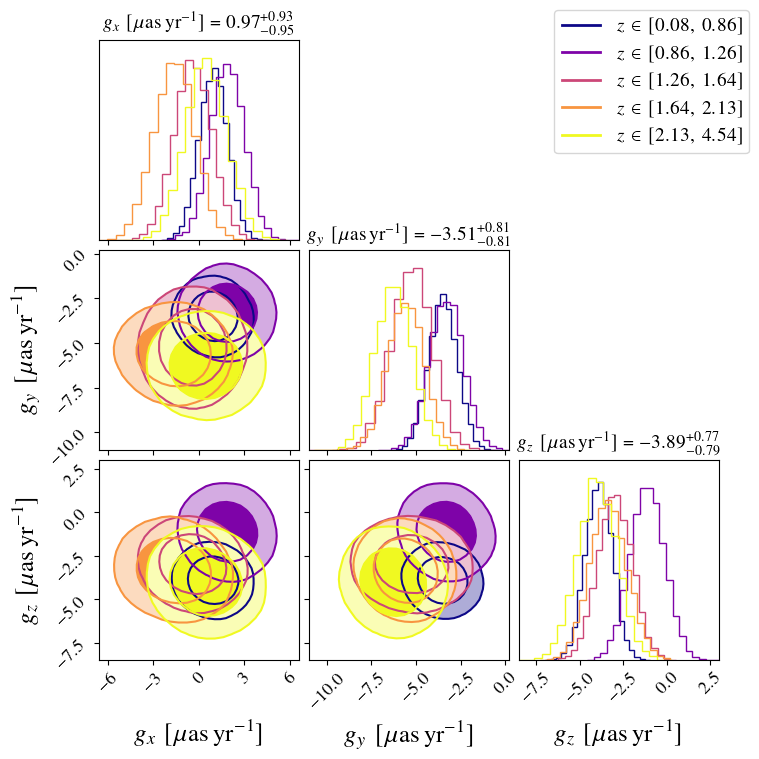

Saved output/zbins/corner_zbins.pdf


In [ ]:
# ── Corner plot: all z-bin posteriors overlaid ───────────────────────────────
import corner

cmap_bins = plt.get_cmap('plasma', N_BINS)
colors    = [cmap_bins(i) for i in range(N_BINS)]
labels    = [r'$g_x\ [\mu\mathrm{as\,yr}^{-1}]$',
             r'$g_y\ [\mu\mathrm{as\,yr}^{-1}]$',
             r'$g_z\ [\mu\mathrm{as\,yr}^{-1}]$']

corner_kw = dict(
    labels=labels,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    smooth=1.5,
    hist2d_kwargs={'bins': 60, 'density': True},
    label_kwargs={'fontsize': 18},
)

fig = None
for i, (r, color) in enumerate(zip(results, colors)):
    fig = corner.corner(
        r['g_full'],
        color=color,
        fig=fig,
        show_titles=(i == 0),   #corner plot shows values of the 1st bin
        title_kwargs={'fontsize': 14, 'pad': 8},
        **corner_kw,
    )

for ax in fig.axes:
    ax.tick_params(labelsize=13)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2,
           label=rf'$z \in [{z_bin_edges[i]:.2f},\,{z_bin_edges[i+1]:.2f}]$')
    for i in range(N_BINS)
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=14,
           bbox_to_anchor=(1.0, 1.0))

plt.savefig(os.path.join(OUT_DIR, 'corner_zbins.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved {os.path.join(OUT_DIR, "corner_zbins.pdf")}')